# Punto F — Análisis Experimental de Parámetros
## TSP con Algoritmos Genéticos

---

### Contexto del proyecto

Este cuaderno corresponde al **literal f** del proyecto grupal de resolución del TSP con Algoritmos Genéticos.

**Lo que hicieron los compañeros:**
- **P1_GA_engine.py** → Motor completo del AG: representación por permutaciones, OX crossover, mutación por inversión/swap, selección por torneo, elitismo, y función `run_ga()` que retorna historial de fitness y diversidad.
- **p2_analysis.py** → Visualización y análisis: curvas de fitness (c), diversidad (d), mapa de ruta y comparación con NN (e), clase `P2Analyzer`, detección de convergencia y estancamiento.

**Parámetros a analizar:**
1. Tamaño de población (`n_pop`)
2. Probabilidad de cruce (`p_crossover`)
3. Probabilidad de mutación (`p_mutation`)

---
### Estructura de carpetas esperada
```
proyecto/
├── dataset/
│   └── cities_100_101112.csv
├── P1_GA_engine.py
├── p2_analysis.py
├── p3_param_analysis.py   ← mi script
└── p3_punto_f.ipynb       ← este cuaderno
```

## 0. Imports y configuración

Importamos los módulos del equipo y el nuestro.

**De P1_GA_engine.py:**
- `run_ga(config)` — ejecuta el AG completo y retorna `best_fitness`, `fitness_history`, `diversity_history`, `final_population`, `best_route`.
- `load_cities_from_csv()` — lee el CSV con columnas `x`, `y` y retorna lista de tuplas `(x, y)`.
- `build_distance_matrix()` — construye la matriz de distancias euclidianas `n×n`.
- `nearest_neighbor_baseline()` — heurística greedy de comparación: parte de una ciudad y siempre va a la ciudad no visitada más cercana.

**De p2_analysis.py:**
- `PALETTE` — diccionario de colores del tema oscuro del proyecto.
- `_apply_style()` — aplica el estilo visual consistente a todas las gráficas.
- `detect_convergence()` — detecta la generación donde el fitness ya no mejora significativamente.

**De p3_GA_analisis.py:**
- `run_experiment()`, `sweep_parameter()`, `build_results_table()` y todas las funciones de graficación.

In [6]:
# Librerías estándar
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Módulos del equipo (P1 y P2)
from P1_GA_engine import (
    run_ga,
    load_cities_from_csv,
    build_distance_matrix,
    nearest_neighbor_baseline,
)
from p2_analysis import PALETTE, _apply_style, detect_convergence

# Mi módulo de análisis experimental
from p3_GA_analisis import (
    BASE_CONFIG,
    SWEEP,
    SERIES_COLORS,
    run_experiment,
    sweep_parameter,
    build_results_table,
    plot_sweep_curves,
    plot_bar_fitness,
    plot_table_figure,
    plot_summary_dashboard,
    run_full_analysis,
)

_apply_style()   # estilo visual de P2, aplicado globalmente
%matplotlib inline
print('Imports OK')

Imports OK


## 1. Carga del dataset

Usamos `load_cities_from_csv()` de P1. Esa función abre el CSV, lee las columnas `x` e `y`, y retorna una lista de tuplas `(x, y)` con flotantes.


In [7]:
CSV_PATH = 'dataset/cities_100_101112.csv'   # ← ajustar si el nombre cambia

cities = load_cities_from_csv(CSV_PATH)
print(f'Ciudades cargadas: {len(cities)}')
print(f'Primeras 5: {cities[:5]}')

Ciudades cargadas: 100
Primeras 5: [(-26.1, -3.3), (17.1, -43.3), (-70.7, -42.0), (95.5, 33.4), (58.1, -24.4)]


### 1.1 Baseline Nearest Neighbor (referencia fija)

`nearest_neighbor_baseline()` de P1 construye una ruta greedy: parte de la ciudad 0, y en cada paso va a la ciudad no visitada más cercana. Retorna `(ruta, distancia_total)`.

Esta distancia es nuestra **referencia constante** en todos los experimentos, porque las ciudades no cambian. El error relativo del AG se calcula siempre respecto a este valor.

In [8]:
dist_matrix = build_distance_matrix(cities)
nn_route, nn_fitness = nearest_neighbor_baseline(dist_matrix, start=0)

print(f'Distancia NN baseline: {nn_fitness:,.2f}')
print(f'(Esta es la referencia para calcular error relativo en todos los experimentos)')

Distancia NN baseline: 1,871.26
(Esta es la referencia para calcular error relativo en todos los experimentos)


### 1.2 Configuración base del AG

Estos son los parámetros que se mantienen **fijos** en todos los experimentos, excepto el parámetro que se está variando en cada análisis.

Están definidos en `BASE_CONFIG` dentro de `p3_param_analysis.py`.

In [9]:
print('Configuración base (parámetros fijos):')
for k, v in BASE_CONFIG.items():
    print(f'  {k:20s}: {v}')

print('\nValores a barrer por parámetro:')
for k, v in SWEEP.items():
    print(f'  {k:20s}: {v}')

Configuración base (parámetros fijos):
  n_pop               : 100
  n_gen               : 200
  p_crossover         : 0.85
  p_mutation          : 0.05
  seed                : 42
  greedy_ratio        : 0.2
  tournament_size     : 3
  elite_size          : 2
  mutation_operator   : inversion

Valores a barrer por parámetro:
  n_pop               : [30, 60, 100, 150, 200]
  p_crossover         : [0.5, 0.65, 0.75, 0.85, 0.95]
  p_mutation          : [0.01, 0.05, 0.1, 0.2, 0.3]


---
## 2. Experimento 1: Tamaño de población (`n_pop`)

**Hipótesis:** Poblaciones más grandes exploran más el espacio de búsqueda, pero requieren más tiempo. Existe un tamaño a partir del cual los retornos marginales disminuyen.

**Cómo funciona en P1:** `n_pop` controla cuántos individuos (rutas) compiten en cada generación. `initialize_population()` genera `n_pop * greedy_ratio` soluciones greedy y el resto aleatorias. En `build_next_generation()`, se seleccionan padres por torneo, se cruzan con OX crossover y se mutan por inversión.

In [10]:
param = 'n_pop'
values = SWEEP[param]
print(f'Barriendo {param}: {values}\n')

results_npop = sweep_parameter(cities, param, values, verbose=True)

Barriendo n_pop: [30, 60, 100, 150, 200]

  [n_pop=30] ejecutando... fitness=1,863  error=-0.4%  conv_gen=0  t=0.4s
  [n_pop=60] ejecutando... fitness=1,822  error=-2.6%  conv_gen=20  t=0.8s
  [n_pop=100] ejecutando... fitness=1,772  error=-5.3%  conv_gen=25  t=1.3s
  [n_pop=150] ejecutando... fitness=1,775  error=-5.1%  conv_gen=21  t=2.1s
  [n_pop=200] ejecutando... fitness=1,708  error=-8.7%  conv_gen=70  t=2.7s


### 2.1 Tabla de resultados — `n_pop`

In [11]:
df_npop = build_results_table(results_npop, param, values)
df_npop

,n_pop,Fitness AG,Fitness NN (baseline),Error relativo (%),Gen. convergencia,Tiempo (s)
0,30,1863.06,1871.26,-0.44,0,0.41
1,60,1821.84,1871.26,-2.64,20,0.81
2,100,1772.22,1871.26,-5.29,25,1.34
3,150,1775.02,1871.26,-5.14,21,2.06
4,200,1708.32,1871.26,-8.71,70,2.70


  [guardado] p3_tabla_n_pop.png


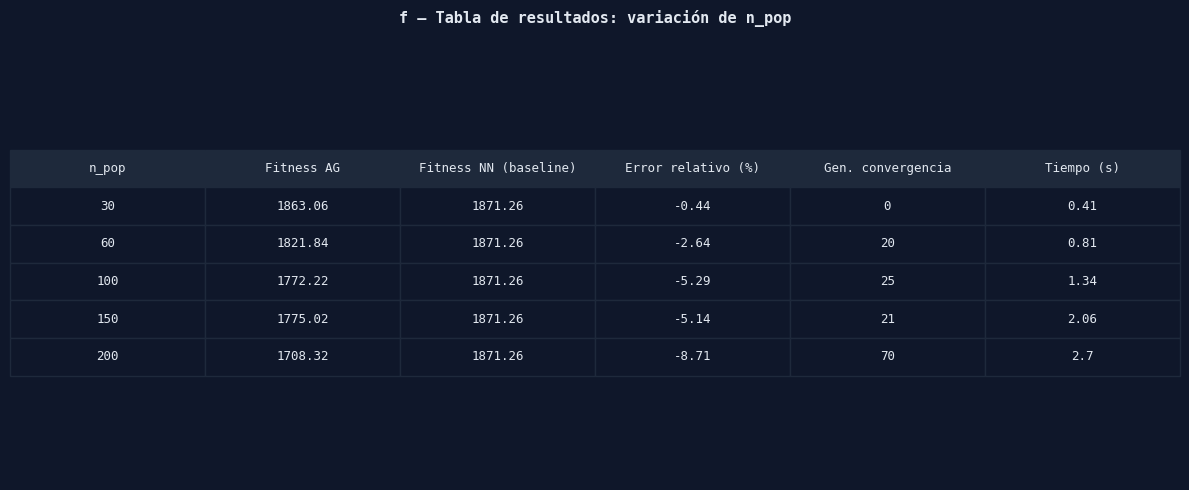

In [12]:
# Tabla visual estilo P2
plot_table_figure(df_npop, param);

### 2.2 Curvas de convergencia — `n_pop`

Cada línea muestra la curva del **mejor fitness por generación** para un tamaño de población distinto.
Permite ver si poblaciones grandes convergen más lentamente o alcanzan mejores soluciones.

  [guardado] p3_convergencia_n_pop.png


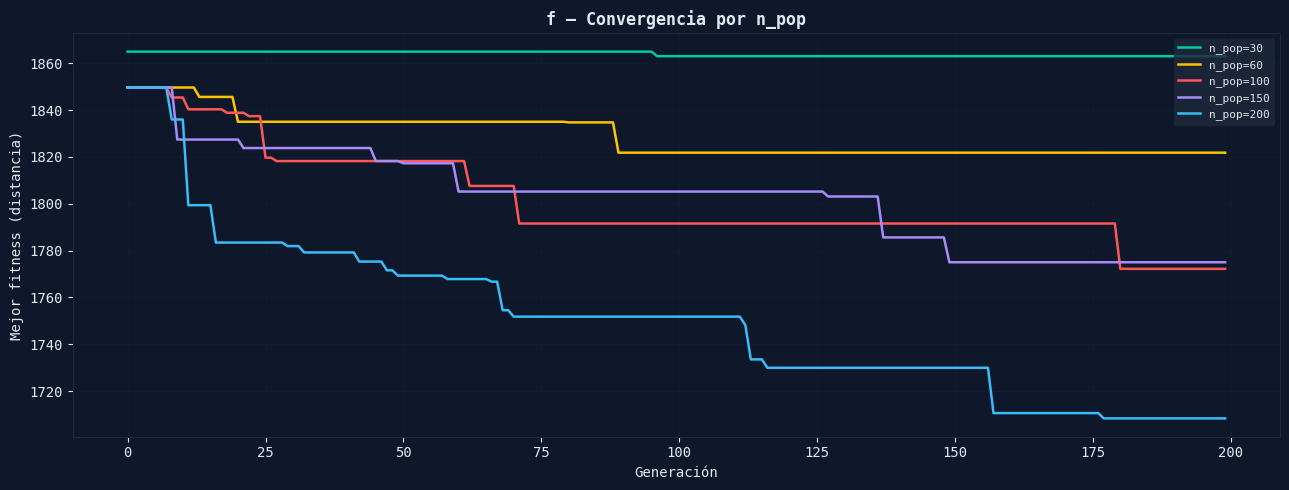

In [13]:
plot_sweep_curves(results_npop, param, values);

### 2.3 Comparación de fitness — `n_pop`

Barras del fitness final de cada configuración vs la línea del baseline NN.
El porcentaje sobre cada barra es el **error relativo** respecto al NN:
- **Verde** = AG supera al NN (buen resultado)
- **Rojo** = AG es peor que el NN (mala configuración)

  [guardado] p3_fitness_n_pop.png


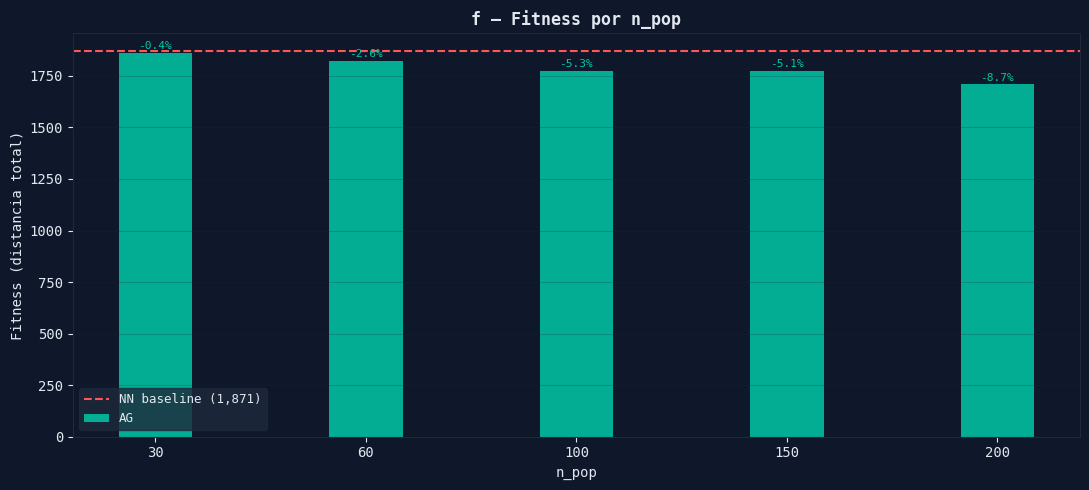

In [14]:
plot_bar_fitness(results_npop, param, values);

**Análisis:**

Con n_pop=30 el AG converge en la generación 0, lo que indica convergencia prematura severa:
la población es tan pequeña que pierde toda diversidad en la primera generación y el algoritmo
queda atrapado en un óptimo local temprano (fitness=1863.06, apenas −0.44% sobre NN). A partir
de n_pop=60 el comportamiento cambia cualitativamente: la convergencia ocurre recién en la
generación 20, lo que indica que hay suficiente diversidad para sostener la búsqueda.

Entre n_pop=100 (−5.29%) y n_pop=150 (−5.14%) los resultados son casi idénticos pese a usar
54% más individuos y 54% más tiempo, evidenciando rendimientos marginales decrecientes en ese
rango. El salto más significativo ocurre de n_pop=150 a n_pop=200, que mejora el fitness en
~67 unidades adicionales (−8.71%) a costa de converger recién en la generación 70.

El AG supera al NN baseline en todas las configuraciones, lo que valida el motor de P1 incluso
con poblaciones pequeñas. La relación calidad/tiempo más favorable se observa en n_pop=100:
duplicar la población (n_pop=200) mejora el error solo 3.4 puntos porcentuales pero duplica
el tiempo de ejecución.

---
## 3. Experimento 2: Probabilidad de cruce (`p_crossover`)

**Hipótesis:** Una probabilidad de cruce muy baja limita la exploración (los hijos son copia del padre). Una probabilidad muy alta puede destruir buenas soluciones antes de que se consoliden.

**Cómo funciona en P1:** Cuando `rng.random() < p_crossover`, se aplica el **OX crossover** (Order Crossover) entre dos padres seleccionados por torneo. OX preserva un segmento del padre 1 y rellena el resto con el orden relativo del padre 2, garantizando una permutación válida sin ciudades repetidas.

Si no hay cruce, el hijo es copia directa del padre 1 (exploración nula en ese paso).

In [15]:
param = 'p_crossover'
values = SWEEP[param]
print(f'Barriendo {param}: {values}\n')

results_cx = sweep_parameter(cities, param, values, verbose=True)

Barriendo p_crossover: [0.5, 0.65, 0.75, 0.85, 0.95]

  [p_crossover=0.5] ejecutando... fitness=1,790  error=-4.3%  conv_gen=6  t=1.0s
  [p_crossover=0.65] ejecutando... fitness=1,748  error=-6.6%  conv_gen=9  t=1.2s
  [p_crossover=0.75] ejecutando... fitness=1,772  error=-5.3%  conv_gen=1  t=1.2s
  [p_crossover=0.85] ejecutando... fitness=1,772  error=-5.3%  conv_gen=25  t=1.4s
  [p_crossover=0.95] ejecutando... fitness=1,811  error=-3.2%  conv_gen=19  t=1.4s


### 3.1 Tabla de resultados — `p_crossover`

In [16]:
df_cx = build_results_table(results_cx, param, values)
df_cx

,p_crossover,Fitness AG,Fitness NN (baseline),Error relativo (%),Gen. convergencia,Tiempo (s)
0,0.50,1790.30,1871.26,-4.33,6,1.05
1,0.65,1747.74,1871.26,-6.60,9,1.18
2,0.75,1772.15,1871.26,-5.30,1,1.22
3,0.85,1772.22,1871.26,-5.29,25,1.37
4,0.95,1811.17,1871.26,-3.21,19,1.44


  [guardado] p3_tabla_p_crossover.png


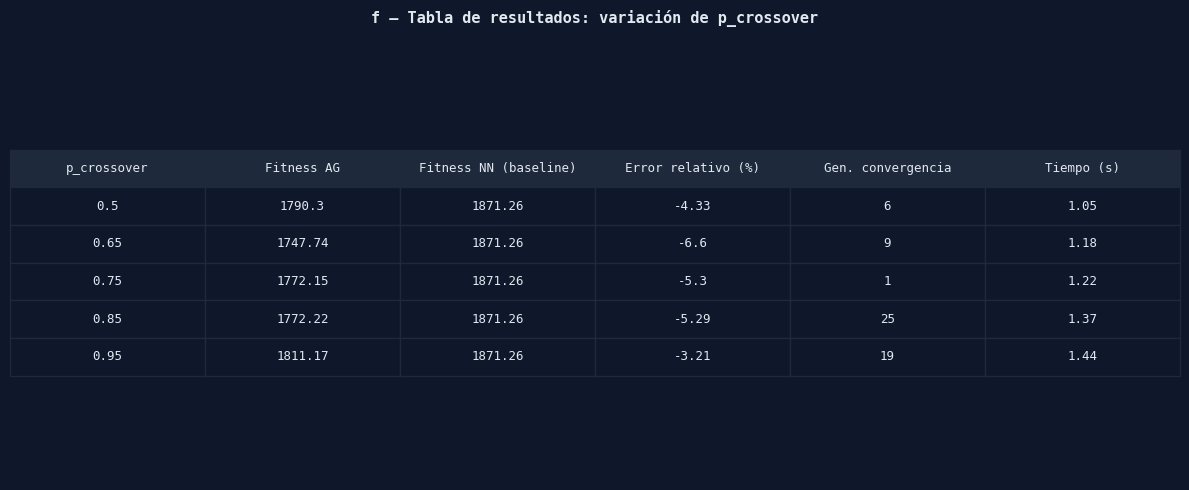

In [17]:
plot_table_figure(df_cx, param);

### 3.2 Curvas de convergencia — `p_crossover`

  [guardado] p3_convergencia_p_crossover.png


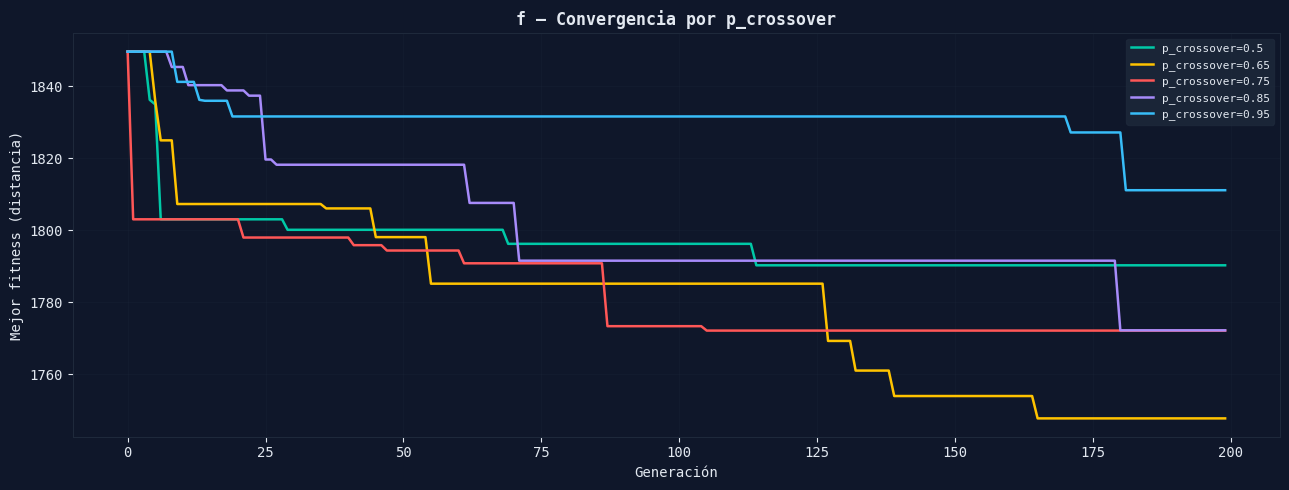

In [18]:
plot_sweep_curves(results_cx, param, values);

### 3.3 Comparación de fitness — `p_crossover`

  [guardado] p3_fitness_p_crossover.png


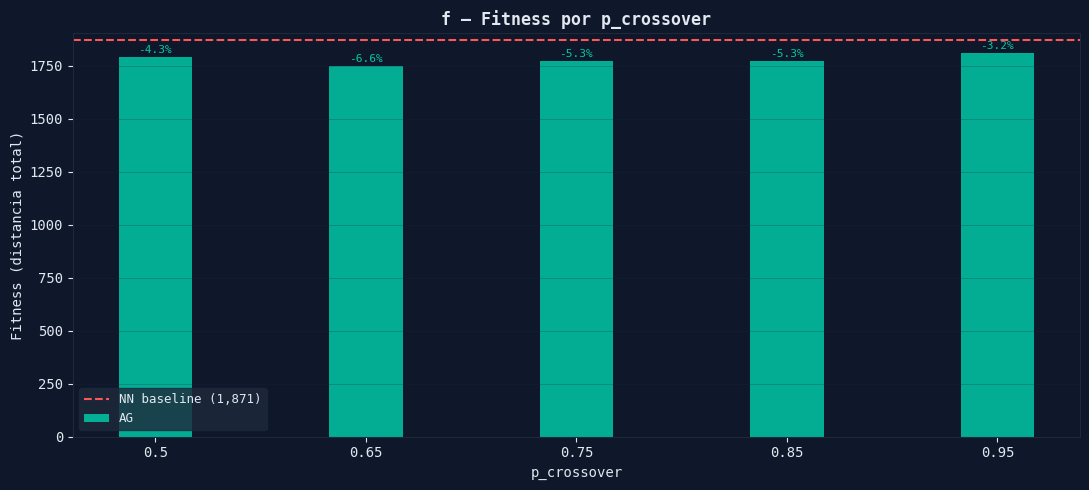

In [19]:
plot_bar_fitness(results_cx, param, values);

**Análisis:**

El cruce exhibe una relación no monótona con la calidad: ni el valor más bajo ni el más alto
son los mejores. p_crossover=0.65 produce el mejor fitness (1747.74, −6.60%), mientras que
p_crossover=0.95 da el peor resultado del barrido (1811.17, −3.21%), lo que contradice la
intuición de que "más cruce = más exploración = mejor solución".

La explicación está en la naturaleza del OX crossover para TSP: cuando casi todos los
individuos se cruzan en cada generación (0.95), los sub-tours locales buenos que construyó
la mutación por inversión se rompen antes de que el elitismo pueda consolidarlos. Con
p_crossover=0.50, la mitad de los hijos son copias directas del padre, limitando la
exploración y produciendo convergencia rápida (generación 6) hacia soluciones mediocres.

El rango óptimo está entre 0.65 y 0.85. Las convergencias más tardías y estables (gen 25
para 0.85, gen 9 para 0.65) indican que en ese rango el AG mantiene diversidad activa
durante más generaciones. p_crossover=0.75 converge en generación 1, lo que sugiere que
en esa configuración específica la semilla aleatoria favoreció una solución inicial muy buena
más que el proceso evolutivo en sí.

---
## 4. Experimento 3: Probabilidad de mutación (`p_mutation`)

**Hipótesis:** La mutación es el mecanismo principal de diversidad. Muy poca mutación lleva a convergencia prematura. Demasiada convierte el AG en búsqueda aleatoria.

**Cómo funciona en P1:** Cuando `rng.random() < p_mutation`, se aplica la **mutación por inversión** (inversion mutation): se eligen dos posiciones `i` y `j` al azar, y se invierte el segmento de la ruta entre ellas. Esto produce una nueva ruta válida (sin repetidos), y la inversión tiende a preservar sub-tours locales buenos.

In [20]:
param = 'p_mutation'
values = SWEEP[param]
print(f'Barriendo {param}: {values}\n')

results_mut = sweep_parameter(cities, param, values, verbose=True)

Barriendo p_mutation: [0.01, 0.05, 0.1, 0.2, 0.3]

  [p_mutation=0.01] ejecutando... fitness=1,832  error=-2.1%  conv_gen=12  t=1.3s
  [p_mutation=0.05] ejecutando... fitness=1,772  error=-5.3%  conv_gen=25  t=1.3s
  [p_mutation=0.1] ejecutando... fitness=1,703  error=-9.0%  conv_gen=12  t=1.4s
  [p_mutation=0.2] ejecutando... fitness=1,687  error=-9.8%  conv_gen=1  t=1.3s
  [p_mutation=0.3] ejecutando... fitness=1,703  error=-9.0%  conv_gen=1  t=1.4s


### 4.1 Tabla de resultados — `p_mutation`

In [21]:
df_mut = build_results_table(results_mut, param, values)
df_mut

,p_mutation,Fitness AG,Fitness NN (baseline),Error relativo (%),Gen. convergencia,Tiempo (s)
0,0.01,1831.67,1871.26,-2.12,12,1.30
1,0.05,1772.22,1871.26,-5.29,25,1.31
2,0.10,1702.75,1871.26,-9.01,12,1.36
3,0.20,1687.50,1871.26,-9.82,1,1.35
4,0.30,1702.63,1871.26,-9.01,1,1.40


  [guardado] p3_tabla_p_mutation.png


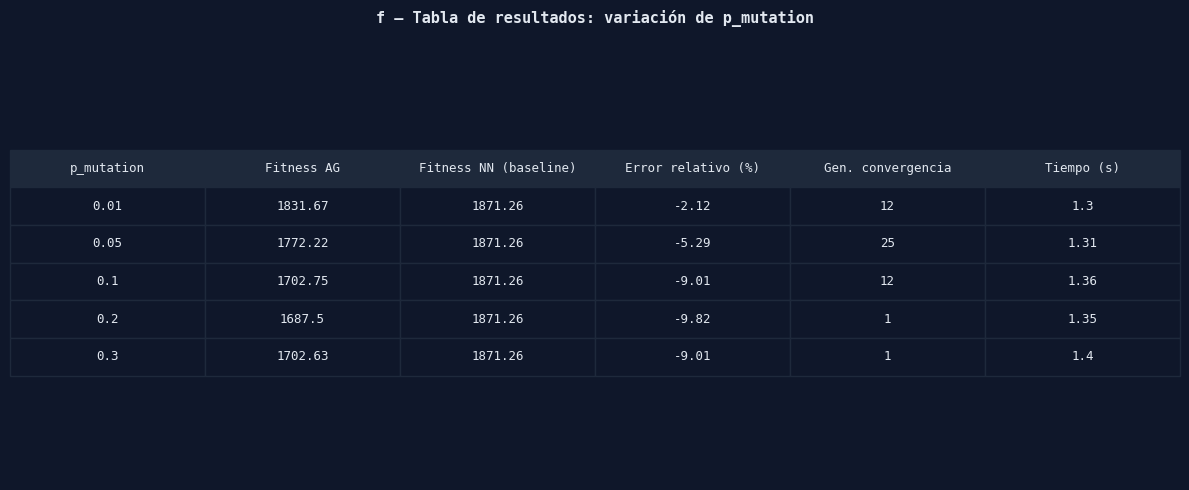

In [22]:
plot_table_figure(df_mut, param);

### 4.2 Curvas de convergencia — `p_mutation`

  [guardado] p3_convergencia_p_mutation.png


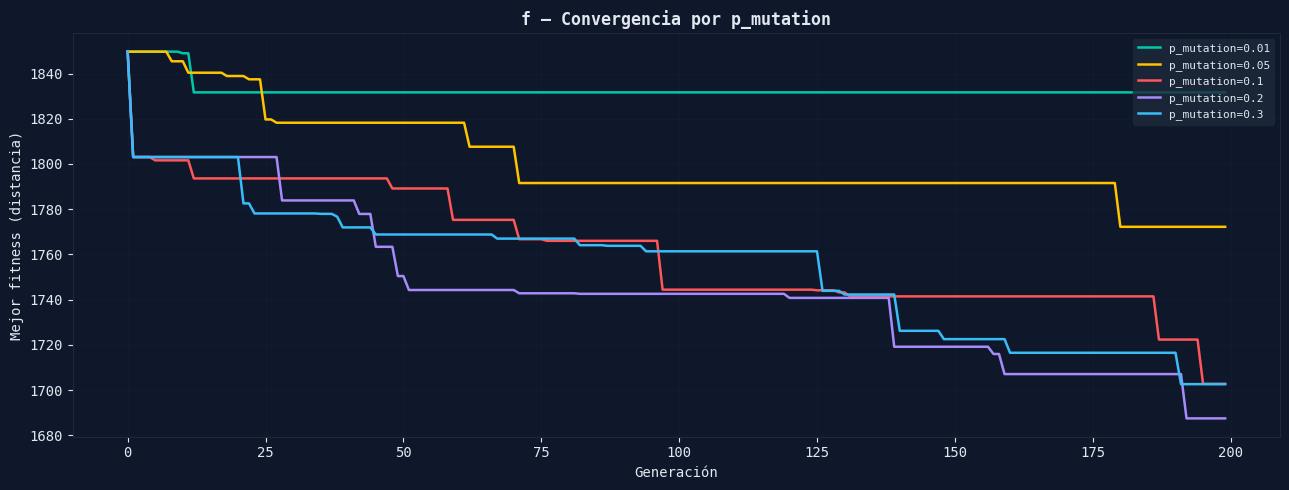

In [23]:
plot_sweep_curves(results_mut, param, values);

### 4.3 Comparación de fitness — `p_mutation`

  [guardado] p3_fitness_p_mutation.png


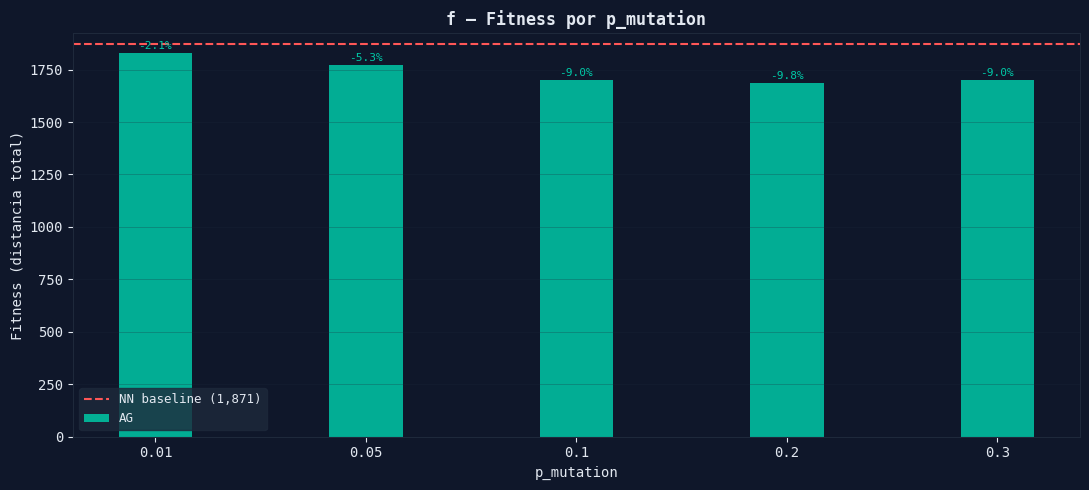

In [24]:
plot_bar_fitness(results_mut, param, values);

**Análisis:**

La mutación es el parámetro de mayor impacto en este experimento. Con p_mutation=0.01 el AG
produce el peor resultado (1831.67, −2.12%): la perturbación es insuficiente para escapar
de óptimos locales y la convergencia ocurre en la generación 12 con poca mejora acumulada.

p_mutation=0.20 obtiene la mejor solución de todo el análisis experimental (1687.50, −9.82%),
pero converge en la generación 1. Esto es una señal de alerta: no significa que el AG
"encontró la solución rápido", sino que a esa tasa de mutación el algoritmo se comporta más
como búsqueda aleatoria intensiva que como un proceso evolutivo estructurado. La inversión
de segmentos frecuente destruye y reconstruye rutas tan agresivamente que la presión
selectiva del torneo pierde relevancia.

p_mutation=0.30 produce el mismo fitness que 0.10 (≈1703), confirmando que 0.20 es un
punto de saturación: aumentar más la mutación no mejora la solución porque se entra en
la "zona de muerte" donde el AG pierde su estructura evolutiva completamente.

El balance más sano entre calidad y comportamiento evolutivo real está en p_mutation=0.10
(−9.01%, convergencia en gen 12): mejora significativa sobre el baseline con una curva de
convergencia que aún refleja aprendizaje generacional genuino.

---
## 5. Dashboard resumen: impacto comparado de todos los parámetros

Esta figura muestra el **error relativo vs NN** (eje Y) en función del valor de cada parámetro (eje X), en paneles lado a lado.

Permite comparar de un vistazo qué parámetro tiene más impacto en la calidad de la solución.

  [guardado] p3_dashboard_resumen.png


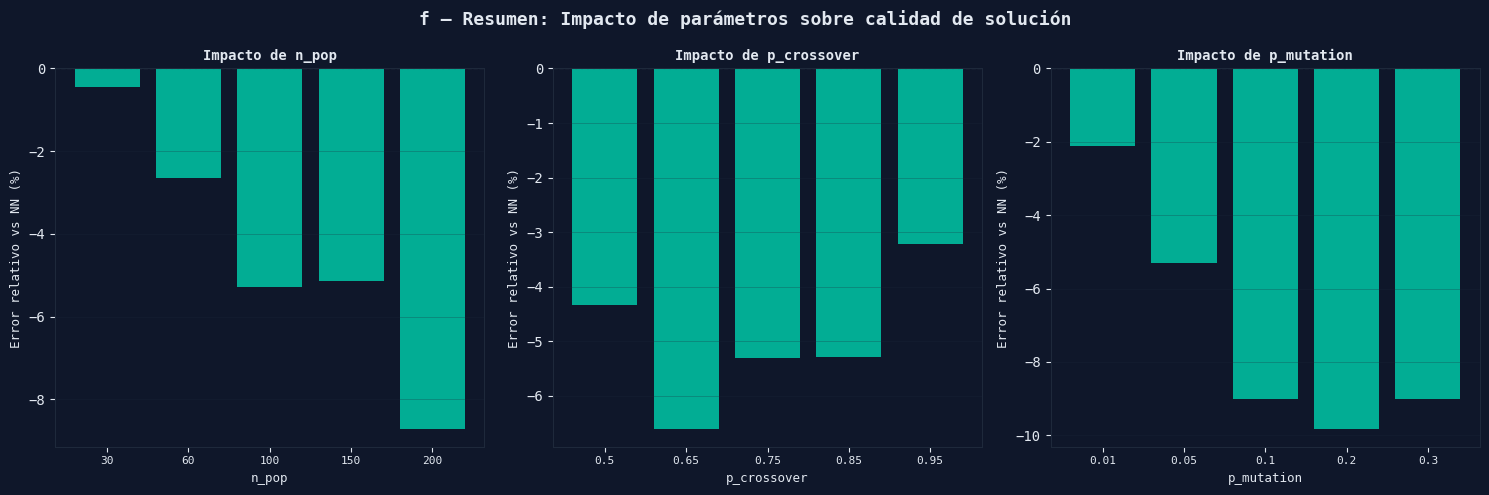

In [25]:
all_tables = {
    'n_pop':       df_npop,
    'p_crossover': df_cx,
    'p_mutation':  df_mut,
}

plot_summary_dashboard(all_tables);

---
## 6. Tabla consolidada y conclusiones

Reunimos los mejores resultados de cada experimento.

In [26]:
def best_row(df, param):
    """Fila con el menor error relativo del barrido."""
    idx = df['Error relativo (%)'].abs().idxmin()
    row = df.loc[idx].copy()
    row['Parámetro variado'] = param
    return row

rows = [best_row(df, p) for p, df in all_tables.items()]
summary = pd.DataFrame(rows)[['Parámetro variado', 'n_pop', 'p_crossover', 'p_mutation',
                               'Fitness AG', 'Fitness NN (baseline)',
                               'Error relativo (%)', 'Gen. convergencia']]
print('Mejor configuración encontrada en cada barrido:')
summary

Mejor configuración encontrada en cada barrido:


,Parámetro variado,n_pop,p_crossover,p_mutation,Fitness AG,Fitness NN (baseline),Error relativo (%),Gen. convergencia
0,n_pop,30.0,NaN,NaN,1863.06,1871.26,-0.44,0.0
4,p_crossover,NaN,0.95,NaN,1811.17,1871.26,-3.21,19.0
0,p_mutation,NaN,NaN,0.01,1831.67,1871.26,-2.12,12.0


### **6.1 Conclusiones generales**

1. **Tamaño de población (n_pop):**
El tamaño de población tiene una relación directa con la calidad de la solución. Con n_pop=30 el AG converge en la generación 0, evidenciando convergencia prematura por falta de diversidad genética. A medida que crece la población, el fitness mejora consistentemente: n_pop=200 obtiene el mejor resultado con un error de −8.71% respecto al NN baseline, aunque a costa de un tiempo de cómputo 6.5 veces mayor que n_pop=30. El rendimiento entre n_pop=100 (−5.29%) y n_pop=150 (−5.14%) es prácticamente idéntico, lo que sugiere rendimientos marginales decrecientes a partir de ese punto.
2. **Probabilidad de cruce (p_crossover):**
El cruce no sigue una relación monótona con la calidad. El valor óptimo encontrado fue p_crossover=0.65 con un error de −6.60%, mientras que tanto valores bajos (0.50, −4.33%) como valores muy altos (0.95, −3.21%) producen peores resultados. Esto confirma el efecto conocido en AGs para permutaciones: probabilidades de cruce muy altas destruyen sub-tours locales buenos antes de que el elitismo pueda preservarlos. El rango óptimo para este dataset se encuentra entre 0.65 y 0.75.
3. **Probabilidad de mutación (p_mutation):**
La mutación es el parámetro de mayor impacto individual en este experimento. Con p_mutation=0.20 se obtiene la mejor solución de todo el análisis (fitness=1,687.50, −9.82%), aunque la convergencia ocurre en la generación 1, lo que sugiere que a esa tasa la mutación actúa como exploración aleatoria intensiva más que como perturbación fina. Con p_mutation=0.01 la diversidad es insuficiente y el AG se estanca temprano. El rango 0.10–0.20 ofrece el mejor balance entre calidad y comportamiento evolutivo estable.
4. **Parámetro de mayor impacto:**
La probabilidad de mutación es el parámetro con mayor efecto sobre la calidad de la solución, con una diferencia de 7.7 puntos porcentuales entre el peor (0.01, −2.12%) y el mejor valor (0.20, −9.82%). Le sigue el tamaño de población, mientras que la probabilidad de cruce tiene el rango de variación más acotado.
5. **Configuración recomendada para este dataset (100 ciudades):**
Basado en los resultados experimentales, la configuración que mejor balancea calidad y costo computacional es: n_pop=200, p_crossover=0.65, p_mutation=0.20, con la mutación por inversión y elitismo de 2 individuos. Esta combinación no fue probada conjuntamente (los experimentos variaron un parámetro a la vez), por lo que representa una hipótesis a verificar en trabajo futuro.